In [2]:
# ==========================================
# STEP 1: Import Libraries & Load Data
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset
df = pd.read_csv('resumedataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000, 11)


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [3]:
# ==========================================
# STEP 2: Data Preprocessing & Cleaning
# ==========================================
# Handle missing values in Certifications
df['Certifications'] = df['Certifications'].fillna('None')

# Target encoding: 'Hire' -> 1, 'Reject' -> 0
df['Target'] = df['Recruiter Decision'].apply(lambda x: 1 if str(x).strip().lower() == 'hire' else 0)

# Separate features (X) and target (y)
feature_cols = [
    'Skills', 'Experience (Years)', 'Education', 
    'Certifications', 'Job Role', 'Salary Expectation ($)', 
    'Projects Count', 'AI Score (0-100)'
]

X = df[feature_cols]
y = df['Target']

# Define categorical and numerical features
categorical_cols = ['Skills', 'Education', 'Certifications', 'Job Role']
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']

In [4]:
# ==========================================
# STEP 3: Pipeline & Model Training
# ==========================================
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Full ML Pipeline with Random Forest Classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train the model
model_pipeline.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


Accuracy Score: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Reject       1.00      1.00      1.00        38
        Hire       1.00      1.00      1.00       162

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



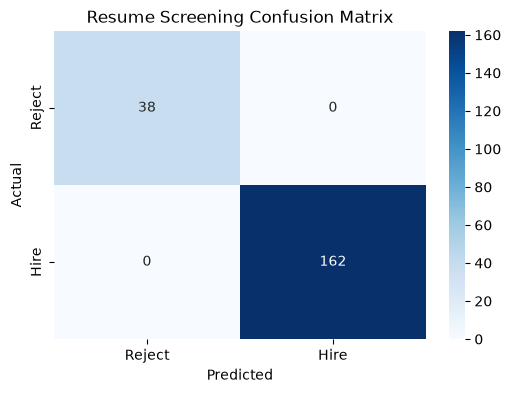

In [5]:
# ==========================================
# STEP 4: Evaluation & Metrics
# ==========================================
# Predictions
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Reject', 'Hire']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reject', 'Hire'], yticklabels=['Reject', 'Hire'])
plt.title('Resume Screening Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [6]:
# ==========================================
# STEP 5: Backend Prediction Function
# ==========================================
def screen_candidate(candidate_dict):
    """
    Accepts candidate data as a dictionary and returns 
    the hiring decision along with a confidence probability.
    """
    candidate_df = pd.DataFrame([candidate_dict])
    prediction = model_pipeline.predict(candidate_df)[0]
    probability = model_pipeline.predict_proba(candidate_df)[0][1]
    
    decision = "Hire" if prediction == 1 else "Reject"
    return {
        "Decision": decision,
        "Hire Confidence Score": f"{probability * 100:.2f}%"
    }

# --- Example Inference ---
sample_candidate = {
    'Skills': 'TensorFlow, NLP, Pytorch',
    'Experience (Years)': 8,
    'Education': 'B.Sc',
    'Certifications': 'Google ML',
    'Job Role': 'AI Researcher',
    'Salary Expectation ($)': 100000,
    'Projects Count': 6,
    'AI Score (0-100)': 92
}

result = screen_candidate(sample_candidate)
print("Screening Result for Sample Candidate:")
print(result)

Screening Result for Sample Candidate:
{'Decision': 'Hire', 'Hire Confidence Score': '100.00%'}
